In [31]:
import networkx as nx
import pandas as pd

# First, let's make sure we have the graph loaded
# If you already have G defined, you can skip this part
try:
    # Check if G exists
    G.number_of_nodes()
except NameError:
    # If G doesn't exist, load it again
    import json
    with open("../../textlab/texts/Others/wil_texter_2.json", "r", encoding="utf-8-sig") as f:
        data = json.load(f)
    
    G = nx.Graph()
    
    # Add nodes from the items
    for item in data["network"]["items"]:
        node_id = str(item["id"])
        label = item["label"]
        
        attrs = {
            "label": label,
            "x": item.get("x", 0),
            "y": item.get("y", 0),
            "cluster": item.get("cluster", 0)
        }
        
        if "weights" in item:
            for weight_name, weight_value in item["weights"].items():
                attr_name = f"weight_{weight_name.replace(' ', '_')}"
                attrs[attr_name] = weight_value
        
        if "scores" in item:
            for score_name, score_value in item["scores"].items():
                attr_name = f"score_{score_name.replace(' ', '_')}"
                attrs[attr_name] = score_value
        
        G.add_node(node_id, **attrs)
    
    # Add edges from the links
    if "links" in data["network"]:
        for link in data["network"]["links"]:
            source = str(link["source_id"])
            target = str(link["target_id"])
            weight = link.get("strength", 1.0)
            G.add_edge(source, target, weight=weight)
    
    print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

# Calculate all three centrality measures
betweenness = nx.betweenness_centrality(G)
closeness = nx.closeness_centrality(G)
eigenvector = nx.eigenvector_centrality(G, max_iter=1000)

# Function to get top nodes by centrality
def get_top_nodes(centrality_dict, n=5):
    return sorted(centrality_dict.items(), key=lambda x: x[1], reverse=True)[:n]

# Get top 5 nodes for each centrality measure
top_betweenness = get_top_nodes(betweenness)
top_closeness = get_top_nodes(closeness)
top_eigenvector = get_top_nodes(eigenvector)

# Print results
print("Top 5 nodes by Betweenness Centrality:")
for node_id, score in top_betweenness:
    label = G.nodes[node_id]["label"]
    print(f"  {label}: {score:.4f}")

print("\nTop 5 nodes by Closeness Centrality:")
for node_id, score in top_closeness:
    label = G.nodes[node_id]["label"]
    print(f"  {label}: {score:.4f}")

print("\nTop 5 nodes by Eigenvector Centrality:")
for node_id, score in top_eigenvector:
    label = G.nodes[node_id]["label"]
    print(f"  {label}: {score:.4f}")

# Create a DataFrame with all centrality measures and node attributes
centrality_data = []
for node_id in G.nodes():
    node_data = G.nodes[node_id]
    centrality_data.append({
        "label": node_data["label"],
        "cluster": node_data.get("cluster", 0),
        "betweenness": betweenness[node_id],
        "closeness": closeness[node_id],
        "eigenvector": eigenvector[node_id],
        "documents": node_data.get("weight_Documents", 0),
        "total_link_strength": node_data.get("weight_Total_link_strength", 0)
    })

df = pd.DataFrame(centrality_data)

# Sort by different centrality measures
print("\nNodes sorted by betweenness centrality:")
print(df.sort_values("betweenness", ascending=False).head()[["label", "cluster", "betweenness"]])

print("\nNodes sorted by closeness centrality:")
print(df.sort_values("closeness", ascending=False).head()[["label", "cluster", "closeness"]])

print("\nNodes sorted by eigenvector centrality:")
print(df.sort_values("eigenvector", ascending=False).head()[["label", "cluster", "eigenvector"]])

# Correlation between centrality measures and other attributes
print("\nCorrelation between centrality measures and document count:")
print(df[["betweenness", "closeness", "eigenvector", "documents", "total_link_strength"]].corr())

Top 5 nodes by Betweenness Centrality:
  lundh snis, ulrika: 0.2858
  johansson, kristina: 0.1601
  vallo hult, helena: 0.1127
  svensson, ann: 0.1100
  svensson, lars: 0.1032

Top 5 nodes by Closeness Centrality:
  lundh snis, ulrika: 0.5605
  vallo hult, helena: 0.4858
  gellerstedt, martin: 0.4637
  pennbrant, sandra: 0.4637
  svensson, lars: 0.4595

Top 5 nodes by Eigenvector Centrality:
  lundh snis, ulrika: 0.3926
  vallo hult, helena: 0.2656
  svensson, lars: 0.2547
  norström, livia: 0.2295
  gellerstedt, martin: 0.2263

Nodes sorted by betweenness centrality:
                  label  cluster  betweenness
58   lundh snis, ulrika        1     0.285803
48  johansson, kristina        1     0.160117
96   vallo hult, helena        1     0.112746
90        svensson, ann        8     0.110023
91       svensson, lars        1     0.103244

Nodes sorted by closeness centrality:
                  label  cluster  closeness
58   lundh snis, ulrika        1   0.560492
96   vallo hult, helen

In [32]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

def remove_nodes_and_analyze(graph, nodes_to_remove):
    """Remove specified nodes and analyze the impact on network metrics"""
    # Make a copy to avoid modifying the original
    modified_graph = graph.copy()
    
    # Store original metrics
    original_metrics = {
        'nodes': modified_graph.number_of_nodes(),
        'edges': modified_graph.number_of_edges(),
        'density': nx.density(modified_graph),
        'components': nx.number_connected_components(modified_graph),
        'clustering': nx.average_clustering(modified_graph)
    }
    
    # If connected, measure path-based metrics
    if nx.is_connected(modified_graph):
        original_metrics['avg_path_length'] = nx.average_shortest_path_length(modified_graph)
        original_metrics['diameter'] = nx.diameter(modified_graph)
    else:
        original_metrics['avg_path_length'] = float('inf')
        original_metrics['diameter'] = float('inf')
    
    # Remove the nodes
    removed_labels = []
    for node in nodes_to_remove:
        if node in modified_graph.nodes():
            removed_labels.append(modified_graph.nodes[node]['label'])
            modified_graph.remove_node(node)
    
    # Calculate new metrics
    new_metrics = {
        'nodes': modified_graph.number_of_nodes(),
        'edges': modified_graph.number_of_edges(),
        'density': nx.density(modified_graph),
        'components': nx.number_connected_components(modified_graph),
        'clustering': nx.average_clustering(modified_graph)
    }
    
    # If connected, measure path-based metrics
    if nx.is_connected(modified_graph):
        new_metrics['avg_path_length'] = nx.average_shortest_path_length(modified_graph)
        new_metrics['diameter'] = nx.diameter(modified_graph)
    else:
        new_metrics['avg_path_length'] = float('inf')
        new_metrics['diameter'] = float('inf')
    
    # Calculate percentage changes
    changes = {}
    for key in original_metrics:
        if original_metrics[key] != 0 and original_metrics[key] != float('inf'):
            changes[key] = (new_metrics[key] - original_metrics[key]) / original_metrics[key] * 100
        else:
            changes[key] = 0
    
    return original_metrics, new_metrics, changes, removed_labels, modified_graph

# Example usage:
# Let's remove the top 3 nodes by betweenness centrality


In [33]:

# Basic graph information
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Graph type: {'Directed' if G.is_directed() else 'Undirected'}")
print(f"Graph density: {nx.density(G):.4f}")

Number of nodes: 105
Number of edges: 360
Graph type: Undirected
Graph density: 0.0659


In [34]:
# Connectivity measures
print(f"Number of connected components: {nx.number_connected_components(G)}")
print(f"Size of largest component: {max(len(comp) for comp in nx.connected_components(G))}")

# Only calculate path-based metrics if the graph is connected
if nx.is_connected(G):
    print(f"Average shortest path length: {nx.average_shortest_path_length(G):.4f}")
    print(f"Diameter: {nx.diameter(G)}")
else:
    print("Graph is not connected - path-based metrics not applicable")

Number of connected components: 2
Size of largest component: 104
Graph is not connected - path-based metrics not applicable


In [35]:
# Clustering coefficient
print(f"Average clustering coefficient: {nx.average_clustering(G):.4f}")

# Transitivity (global clustering)
print(f"Transitivity: {nx.transitivity(G):.4f}")

Average clustering coefficient: 0.4958
Transitivity: 0.3396


In [36]:
# Different centrality measures
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G)

# Find nodes with highest values for each centrality
print("\nTop nodes by centrality measures:")
print(f"Degree centrality: {max(degree_centrality, key=degree_centrality.get)}")
print(f"Betweenness centrality: {max(betweenness_centrality, key=betweenness_centrality.get)}")
print(f"Closeness centrality: {max(closeness_centrality, key=closeness_centrality.get)}")
print(f"Eigenvector centrality: {max(eigenvector_centrality, key=eigenvector_centrality.get)}")


Top nodes by centrality measures:
Degree centrality: 543
Betweenness centrality: 543
Closeness centrality: 543
Eigenvector centrality: 543


In [37]:
# Degree statistics
degrees = [G.degree(n) for n in G.nodes()]
print(f"\nDegree statistics:")
print(f"Average degree: {sum(degrees)/len(degrees):.2f}")
print(f"Minimum degree: {min(degrees)}")
print(f"Maximum degree: {max(degrees)}")


Degree statistics:
Average degree: 6.86
Minimum degree: 0
Maximum degree: 42


In [38]:
# Degree assortativity (do nodes connect to similar nodes?)
if G.number_of_edges() > 0:
    print(f"\nDegree assortativity: {nx.degree_assortativity_coefficient(G):.4f}")


Degree assortativity: -0.0457


In [39]:
# Let's calculate some additional metrics to understand your network better

# Average degree (average number of collaborators per researcher)
avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
print(f"Average degree: {avg_degree:.2f}")

# This means the average researcher collaborates with about 6.86 others
# For academic co-authorship networks, this is actually quite healthy!

# Check if your network has a giant component
components = list(nx.connected_components(G))
largest_component_size = max(len(comp) for comp in components)
print(f"Largest component size: {largest_component_size}")
print(f"Percentage of nodes in largest component: {largest_component_size/G.number_of_nodes():.2%}")

# Small-world property check
if nx.is_connected(G):
    avg_path_length = nx.average_shortest_path_length(G)
    clustering = nx.average_clustering(G)
    
    # Compare with random graph of same size and density
    random_graph = nx.erdos_renyi_graph(G.number_of_nodes(), nx.density(G))
    random_clustering = nx.average_clustering(random_graph)
    
    print(f"\nSmall-world properties:")
    print(f"Average path length: {avg_path_length:.2f}")
    print(f"Clustering coefficient: {clustering:.4f}")
    print(f"Random graph clustering: {random_clustering:.4f}")
    print(f"Clustering ratio (actual/random): {clustering/random_clustering:.2f}")
    
    if clustering / random_clustering > 3:
        print("Your network shows strong small-world properties!")

Average degree: 6.86
Largest component size: 104
Percentage of nodes in largest component: 99.05%


In [40]:
import networkx as nx

# Find all connected components
components = list(nx.connected_components(G))

# Sort components by size (largest first)
components.sort(key=len, reverse=True)

# Get the largest component
largest_component_nodes = components[0]
largest_component = G.subgraph(largest_component_nodes).copy()

print(f"Original graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Largest component: {largest_component.number_of_nodes()} nodes, {largest_component.number_of_edges()} edges")
print(f"Number of components removed: {len(components) - 1}")
print(f"Nodes removed: {G.number_of_nodes() - largest_component.number_of_nodes()}")

# Now you can run path-based analyses on the largest component
if nx.is_connected(largest_component):
    print(f"\nPath-based metrics for largest component:")
    print(f"Average shortest path length: {nx.average_shortest_path_length(largest_component):.4f}")
    print(f"Diameter: {nx.diameter(largest_component)}")
    print(f"Radius: {nx.radius(largest_component)}")
    print(f"Center: {nx.center(largest_component)}")

Original graph: 105 nodes, 360 edges
Largest component: 104 nodes, 360 edges
Number of components removed: 1
Nodes removed: 1

Path-based metrics for largest component:
Average shortest path length: 2.9108
Diameter: 8
Radius: 4
Center: ['543', '656', '853']


In [41]:
# Identify the center nodes
center_nodes = ['543', '656', '853']
print("Center nodes in your network:")
for node_id in center_nodes:
    label = G.nodes[node_id]['label']
    print(f"ID {node_id}: {label}")
    # Show some basic info about each center node
    degree = G.degree(node_id)
    cluster = G.nodes[node_id].get('cluster', 'N/A')
    print(f"  Degree: {degree}, Cluster: {cluster}")

Center nodes in your network:
ID 543: lundh snis, ulrika
  Degree: 42, Cluster: 1
ID 656: pennbrant, sandra
  Degree: 11, Cluster: 5
ID 853: vallo hult, helena
  Degree: 27, Cluster: 1


In [42]:
import networkx as nx

# Compare with a random graph of same size and density
random_graph = nx.erdos_renyi_graph(largest_component.number_of_nodes(), nx.density(largest_component))

# Calculate clustering coefficients
actual_clustering = nx.average_clustering(largest_component)
random_clustering = nx.average_clustering(random_graph)

# Calculate average path lengths
actual_path_length = nx.average_shortest_path_length(largest_component)
random_path_length = nx.average_shortest_path_length(random_graph)

print("Small-world analysis:")
print(f"Actual clustering coefficient: {actual_clustering:.4f}")
print(f"Random clustering coefficient: {random_clustering:.4f}")
print(f"Clustering ratio (actual/random): {actual_clustering/random_clustering:.2f}")

print(f"\nActual average path length: {actual_path_length:.4f}")
print(f"Random average path length: {random_path_length:.4f}")

# Small-world networks have high clustering and short path lengths
if actual_clustering/random_clustering > 3 and actual_path_length < random_path_length:
    print("\nYour network exhibits strong small-world properties!")
    print("This is typical of academic collaboration networks.")

Small-world analysis:
Actual clustering coefficient: 0.5005
Random clustering coefficient: 0.0779
Clustering ratio (actual/random): 6.43

Actual average path length: 2.9108
Random average path length: 2.6505


In [43]:
# Let's explore the implications of these small-world properties
import networkx as nx

# Identify potential "bridges" between clusters
bridges = list(nx.bridges(largest_component))
print(f"Number of bridges in the network: {len(bridges)}")

# Find nodes with high betweenness centrality (potential knowledge brokers)
betweenness = nx.betweenness_centrality(largest_component)
top_bridges = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]

print("\nTop 5 potential knowledge brokers (highest betweenness):")
for node_id, score in top_bridges:
    label = largest_component.nodes[node_id]['label']
    cluster = largest_component.nodes[node_id].get('cluster', 'N/A')
    print(f"{label} (Cluster {cluster}): {score:.4f}")

# Check how clusters are connected
clusters = {}
for node in largest_component.nodes():
    cluster_id = largest_component.nodes[node].get('cluster', 0)
    if cluster_id not in clusters:
        clusters[cluster_id] = []
    clusters[cluster_id].append(node)

print(f"\nYour network has {len(clusters)} clusters")
for cluster_id, nodes in clusters.items():
    print(f"Cluster {cluster_id}: {len(nodes)} nodes")

Number of bridges in the network: 14

Top 5 potential knowledge brokers (highest betweenness):
lundh snis, ulrika (Cluster 1): 0.2914
johansson, kristina (Cluster 1): 0.1633
vallo hult, helena (Cluster 1): 0.1150
svensson, ann (Cluster 8): 0.1122
svensson, lars (Cluster 1): 0.1053

Your network has 13 clusters
Cluster 8: 6 nodes
Cluster 7: 6 nodes
Cluster 4: 8 nodes
Cluster 1: 27 nodes
Cluster 13: 3 nodes
Cluster 9: 5 nodes
Cluster 2: 13 nodes
Cluster 10: 4 nodes
Cluster 3: 11 nodes
Cluster 5: 7 nodes
Cluster 12: 4 nodes
Cluster 6: 6 nodes
Cluster 11: 4 nodes


Node centrality measures:
   id                         label  cluster  degree  degree_centrality  \
0   7                aggestam, lena        8       3           0.029126   
1  29             andersson, mikael        7       2           0.019417   
2  42  areskoug josefsson, kristina        4      10           0.097087   
3  43  arghavan shahlaei, charlotte        1       6           0.058252   
4  48                arvemo, tobias       13       6           0.058252   

   betweenness_centrality  closeness_centrality  eigenvector_centrality  
0                0.005466              0.353952                0.029300  
1                0.000000              0.323899                0.030564  
2                0.042028              0.412000                0.059675  
3                0.002475              0.381481                0.082815  
4                0.001975              0.400778                0.078554  


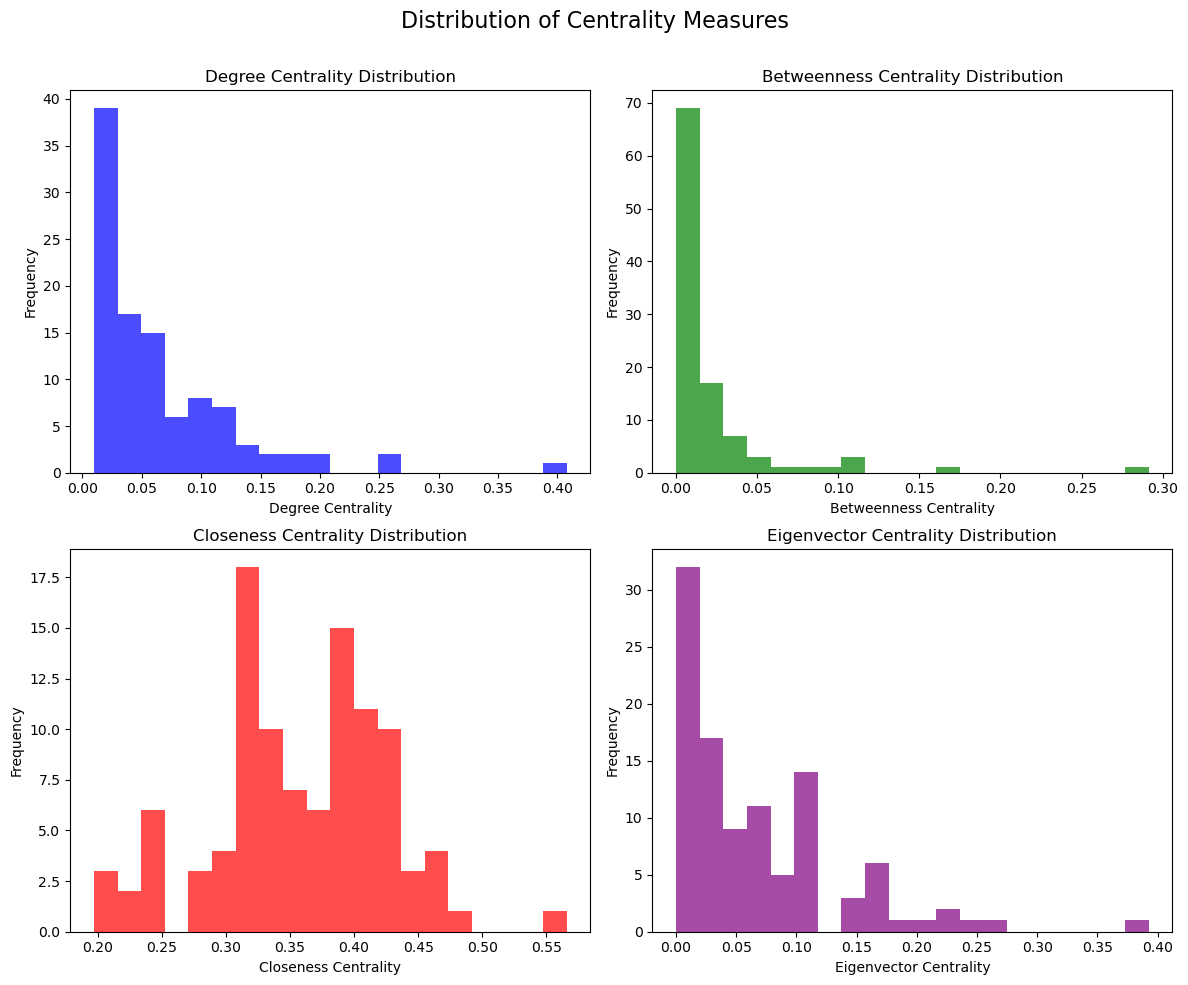


Summary Statistics:
       degree_centrality  betweenness_centrality  closeness_centrality  \
count         104.000000              104.000000            104.000000   
mean            0.067214                0.018733              0.357872   
std             0.063017                0.039074              0.067838   
min             0.009709                0.000000              0.196941   
25%             0.019417                0.000000              0.319382   
50%             0.048544                0.002647              0.358889   
75%             0.097087                0.019417              0.405124   
max             0.407767                0.291407              0.565934   

       eigenvector_centrality  
count              104.000000  
mean                 0.068384  
std                  0.070618  
min                  0.000060  
25%                  0.013275  
50%                  0.044952  
75%                  0.106153  
max                  0.392585  


In [44]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Calculate all centrality measures
degree_centrality = nx.degree_centrality(largest_component)
betweenness_centrality = nx.betweenness_centrality(largest_component)
closeness_centrality = nx.closeness_centrality(largest_component)
eigenvector_centrality = nx.eigenvector_centrality(largest_component)

# Create a DataFrame with all node data
node_data = []
for node in largest_component.nodes():
    node_info = largest_component.nodes[node]
    node_data.append({
        'id': node,
        'label': node_info['label'],
        'cluster': node_info.get('cluster', 'N/A'),
        'degree': largest_component.degree(node),
        'degree_centrality': degree_centrality[node],
        'betweenness_centrality': betweenness_centrality[node],
        'closeness_centrality': closeness_centrality[node],
        'eigenvector_centrality': eigenvector_centrality[node]
    })

df = pd.DataFrame(node_data)

# Display the first few rows
print("Node centrality measures:")
print(df.head())

# Save the DataFrame to CSV if you want to analyze it elsewhere
df.to_csv('node_centrality_measures.csv', index=False)

# Create histograms for each centrality measure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribution of Centrality Measures', fontsize=16)

# Degree centrality histogram
axes[0, 0].hist(df['degree_centrality'], bins=20, alpha=0.7, color='blue')
axes[0, 0].set_title('Degree Centrality Distribution')
axes[0, 0].set_xlabel('Degree Centrality')
axes[0, 0].set_ylabel('Frequency')

# Betweenness centrality histogram
axes[0, 1].hist(df['betweenness_centrality'], bins=20, alpha=0.7, color='green')
axes[0, 1].set_title('Betweenness Centrality Distribution')
axes[0, 1].set_xlabel('Betweenness Centrality')
axes[0, 1].set_ylabel('Frequency')

# Closeness centrality histogram
axes[1, 0].hist(df['closeness_centrality'], bins=20, alpha=0.7, color='red')
axes[1, 0].set_title('Closeness Centrality Distribution')
axes[1, 0].set_xlabel('Closeness Centrality')
axes[1, 0].set_ylabel('Frequency')

# Eigenvector centrality histogram
axes[1, 1].hist(df['eigenvector_centrality'], bins=20, alpha=0.7, color='purple')
axes[1, 1].set_title('Eigenvector Centrality Distribution')
axes[1, 1].set_xlabel('Eigenvector Centrality')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# Summary statistics
print("\nSummary Statistics:")
print(df[['degree_centrality', 'betweenness_centrality', 'closeness_centrality', 'eigenvector_centrality']].describe())

# Find nodes with highest values for each centr

In [ ]:
# If you already know the specific node IDs
specific_node_ids = ['236', '416', '80','807','543']  # Replace with your actual node IDs

# Use the analysis function with these specific node IDs
original, new, changes, removed_labels, modified_graph = remove_nodes_and_analyze(largest_component, specific_node_ids)

print(f"\nRemoved nodes: {removed_labels}")
print("\nImpact on network metrics:")
for metric in ['nodes', 'edges', 'density', 'components', 'clustering']:
    print(f"{metric}: {original[metric]:.4f} → {new[metric]:.4f} ({changes[metric]:.2f}%)")

if original['avg_path_length'] != float('inf'):
    print(f"Avg Path Length: {original['avg_path_length']:.4f} → {new['avg_path_length']:.4f} ({changes['avg_path_length']:.2f}%)")


Removed nodes: ['flensburg, per', 'johansson, kristina', 'bernhardsson, lennarth', 'svensson, lars']

Impact on network metrics:
nodes: 104.0000 → 100.0000 (-3.85%)
edges: 360.0000 → 298.0000 (-17.22%)
density: 0.0672 → 0.0602 (-10.43%)
components: 1.0000 → 4.0000 (300.00%)
clustering: 0.5005 → 0.4522 (-9.65%)
Avg Path Length: 2.9108 → inf (inf%)


In [46]:
# Let's look at these key researchers in more detail
departed_researchers = ['flensburg, per', 'johansson, kristina', 'bernhardsson, lennarth', 'svensson, lars']

# Check their centrality measures and clusters
for name in departed_researchers:
    matching_nodes = df[df['label'].str.lower() == name.lower()]
    if not matching_nodes.empty:
        node_info = matching_nodes.iloc[0]
        print(f"{node_info['label']}:")
        print(f"  Degree: {node_info['degree']} (centrality: {node_info['degree_centrality']:.4f})")
        print(f"  Betweenness: {node_info['betweenness_centrality']:.4f}")
        print(f"  Closeness: {node_info['closeness_centrality']:.4f}")
        print(f"  Cluster: {node_info['cluster']}")
        print()

# Let's see what clusters they connected
for name in departed_researchers:
    matching_nodes = df[df['label'].str.lower() == name.lower()]
    if not matching_nodes.empty:
        node_id = matching_nodes.iloc[0]['id']
        if node_id in largest_component.nodes():
            neighbors = list(largest_component.neighbors(node_id))
            neighbor_clusters = set()
            for neighbor in neighbors:
                neighbor_clusters.add(largest_component.nodes[neighbor].get('cluster', 'Unknown'))
            
            print(f"{name} connected to clusters: {sorted(neighbor_clusters)}")

flensburg, per:
  Degree: 5 (centrality: 0.0485)
  Betweenness: 0.0002
  Closeness: 0.3422
  Cluster: 7

johansson, kristina:
  Degree: 20 (centrality: 0.1942)
  Betweenness: 0.1633
  Closeness: 0.4619
  Cluster: 1

bernhardsson, lennarth:
  Degree: 13 (centrality: 0.1262)
  Betweenness: 0.0175
  Closeness: 0.4274
  Cluster: 7

svensson, lars:
  Degree: 27 (centrality: 0.2621)
  Betweenness: 0.1053
  Closeness: 0.4640
  Cluster: 1

flensburg, per connected to clusters: [1, 2, 6, 7]
johansson, kristina connected to clusters: [1, 2, 5, 6, 7, 11]
bernhardsson, lennarth connected to clusters: [1, 2, 5, 6, 7]
svensson, lars connected to clusters: [1, 2, 3, 5, 6, 7, 12]
